# Task 2: Bayesian Change Point Analysis of Brent Oil Prices

**Prepared by:** Rediet Shewarega  
**Client:** Birhan Energies

## Objective

This notebook applies Bayesian change point detection to identify and quantify a structural change in historical Brent crude oil prices.

The analysis will:

- Load and validate the Brent oil price dataset
- Examine raw prices and log returns
- Define a Bayesian switch-point model using PyMC
- Estimate price parameters before and after the structural change
- Evaluate MCMC convergence and posterior uncertainty
- Convert the detected switch-point index into a calendar date
- Quantify the estimated price impact
- Compare the detected date with major geopolitical, economic, sanctions-related, and OPEC events

Temporal proximity between a detected change and a historical event is interpreted as an association, not definitive evidence of causation.

In [4]:
from pathlib import Path
import json
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from statsmodels.tsa.stattools import adfuller

# Determine the repository root.
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "BrentOilPrices.csv"
)

cleaned_data_path = (
    project_root
    / "data"
    / "processed"
    / "brent_oil_prices_cleaned.csv"
)

events_path = (
    project_root
    / "data"
    / "events"
    / "oil_market_events.csv"
)

processed_directory = project_root / "data" / "processed"
figures_directory = project_root / "reports" / "figures"

processed_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

print("Python version:", sys.version)
print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)
print("Project root:", project_root)

Python version: 3.14.5 (main, May 10 2026, 10:21:34) [Clang 21.0.0 (clang-2100.0.123.102)]
PyMC version: 6.1.0
ArviZ version: 1.2.0
Project root: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis


In [5]:
# Prefer the cleaned Task 1 dataset when it exists.
data_path = (
    cleaned_data_path
    if cleaned_data_path.exists()
    else raw_data_path
)

print("Loading dataset from:", data_path)

df = pd.read_csv(data_path)

required_columns = {"Date", "Price"}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

# Convert Date. The raw file uses values such as 20-May-87.
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y",
    errors="coerce"
)

# This fallback supports a processed file that already uses ISO dates.
if df["Date"].isna().all():
    df["Date"] = pd.to_datetime(
        pd.read_csv(data_path)["Date"],
        errors="coerce"
    )

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df = (
    df.dropna(subset=["Date", "Price"])
      .drop_duplicates(subset=["Date"])
      .sort_values("Date")
      .reset_index(drop=True)
)

# Calculate daily log returns.
df["Log_Return"] = np.log(df["Price"]).diff()

print("Dataset shape:", df.shape)
print(
    "Date range:",
    df["Date"].min().date(),
    "to",
    df["Date"].max().date()
)
print("Duplicate dates:", df["Date"].duplicated().sum())
print("\nMissing values:")
print(df.isna().sum())

df.head()

Loading dataset from: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/data/processed/brent_oil_prices_cleaned.csv
Dataset shape: (8360, 3)
Date range: 1987-05-20 to 2020-04-21
Duplicate dates: 0

Missing values:
Date          0
Price         0
Log_Return    1
dtype: int64


,Date,Price,Log_Return
0,1987-05-20,18.63,NaN
1,1987-05-21,18.45,-0.009709
2,1987-05-22,18.55,0.005405
3,1987-05-25,18.60,0.002692
4,1987-05-26,18.63,0.001612


In [6]:
price_statistics = pd.Series(
    {
        "Number of observations": len(df),
        "Average price": df["Price"].mean(),
        "Median price": df["Price"].median(),
        "Minimum price": df["Price"].min(),
        "Maximum price": df["Price"].max(),
        "Price standard deviation": df["Price"].std(),
    }
)

price_statistics

Number of observations      8360.000000
Average price                 46.459669
Median price                  31.750000
Minimum price                  9.100000
Maximum price                143.950000
Price standard deviation      32.504671
dtype: float64

### Data preparation interpretation

The dataset was converted into chronological time-series format, with invalid dates and prices removed and duplicate dates checked. Daily log returns were calculated to represent relative price movements.

The raw price series will be used for the mandatory before-and-after mean change model. Log returns are used separately to examine stationarity and volatility clustering.

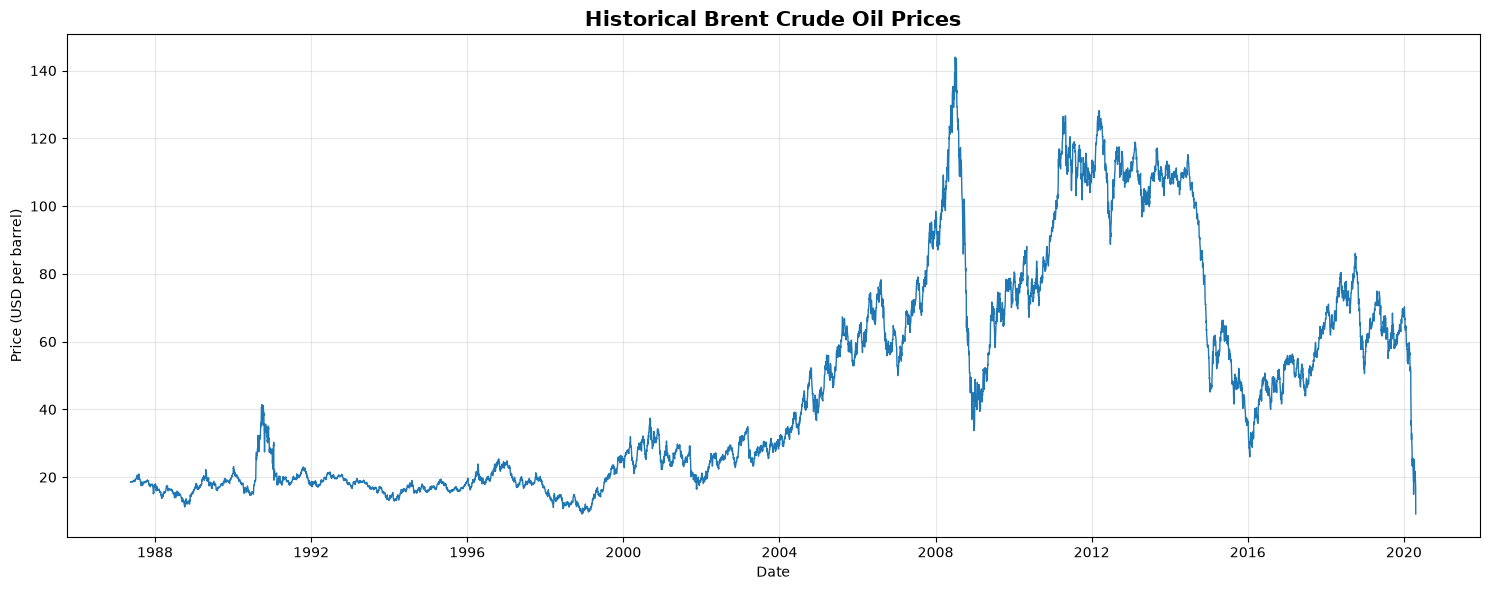

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_raw_price_series.png


In [7]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Price"],
    linewidth=1
)

plt.title(
    "Historical Brent Crude Oil Prices",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.grid(alpha=0.3)
plt.tight_layout()

raw_price_figure = (
    figures_directory
    / "task2_raw_price_series.png"
)

plt.savefig(
    raw_price_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", raw_price_figure)

### Raw price interpretation

The historical Brent price series exhibits substantial long-term variation, major shocks, and apparent changes in average price levels. The series does not fluctuate around one stable mean throughout the full period.

The visible changes in price level support the use of structural-break analysis. However, visual inspection alone cannot determine the most probable change date or quantify uncertainty around it.

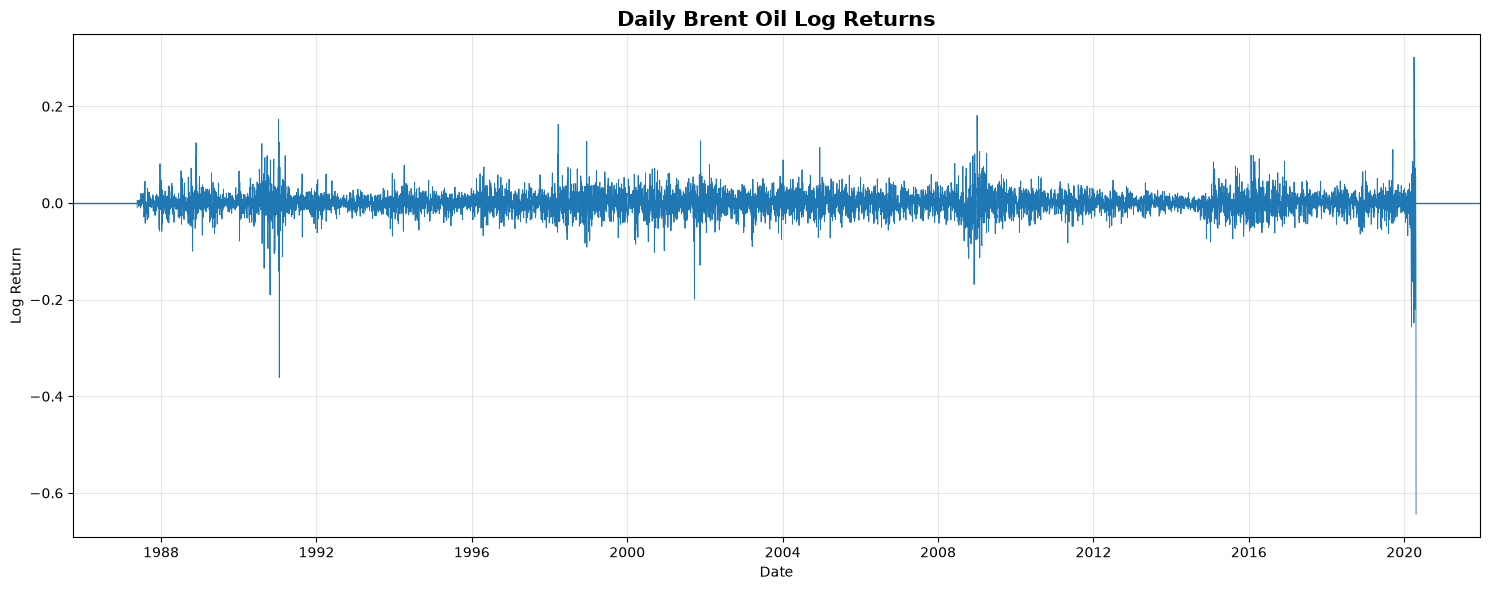

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_log_returns.png


In [8]:
returns_df = df.dropna(
    subset=["Log_Return"]
).copy()

plt.figure(figsize=(15, 6))

plt.plot(
    returns_df["Date"],
    returns_df["Log_Return"],
    linewidth=0.65
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Daily Brent Oil Log Returns",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(alpha=0.3)
plt.tight_layout()

log_return_figure = (
    figures_directory
    / "task2_log_returns.png"
)

plt.savefig(
    log_return_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", log_return_figure)

### Log-return interpretation

The log-return series fluctuates around approximately zero, but the magnitude of the movements is not constant.

Large positive and negative movements frequently occur close together. This pattern is consistent with volatility clustering, where turbulent market periods contain repeated large price movements.

This indicates that the constant-variance assumption in the simple Normal change point model is a simplification of real oil-market behaviour.

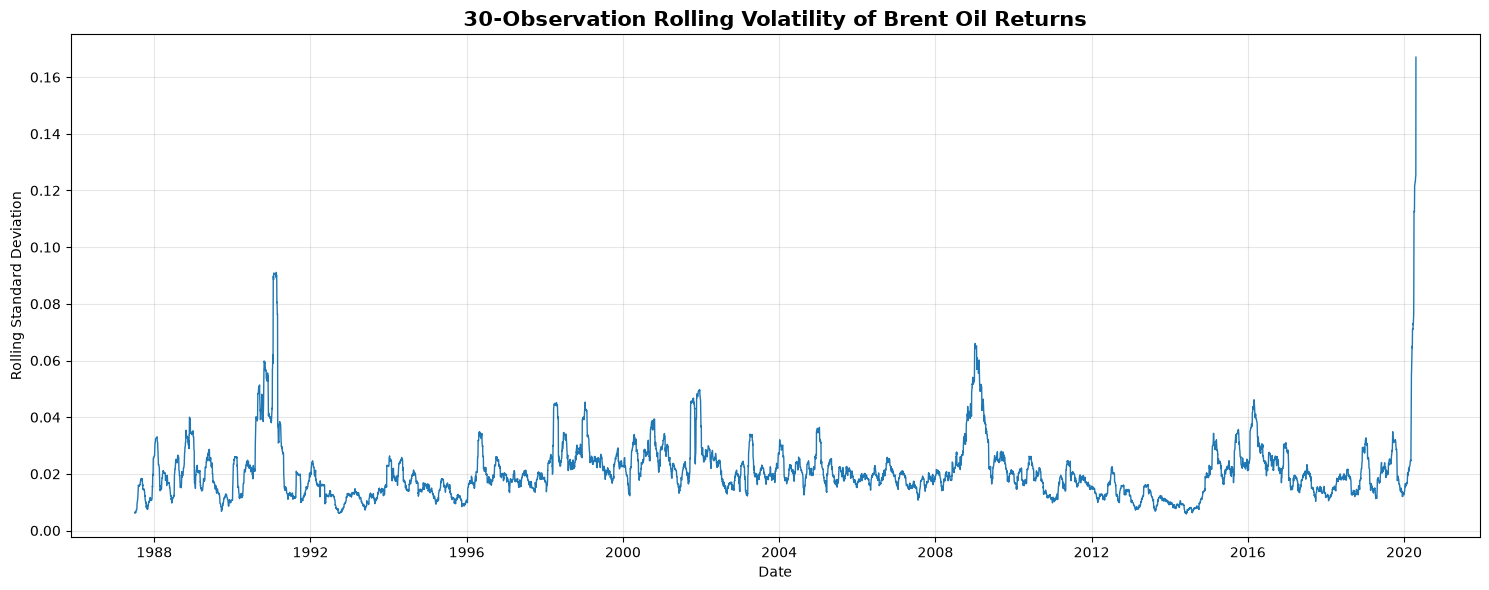

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_rolling_volatility.png


In [9]:
returns_df["Rolling_Volatility_30"] = (
    returns_df["Log_Return"]
    .rolling(window=30)
    .std()
)

plt.figure(figsize=(15, 6))

plt.plot(
    returns_df["Date"],
    returns_df["Rolling_Volatility_30"],
    linewidth=1
)

plt.title(
    "30-Observation Rolling Volatility of Brent Oil Returns",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(alpha=0.3)
plt.tight_layout()

volatility_figure = (
    figures_directory
    / "task2_rolling_volatility.png"
)

plt.savefig(
    volatility_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", volatility_figure)

### Volatility interpretation

Rolling volatility changes substantially over time. Periods of relatively stable price movements are interrupted by pronounced volatility spikes.

This confirms that the Brent oil market experiences different volatility regimes. The mandatory mean-change model does not directly model these variance changes, so more advanced volatility or regime-switching models are recommended as future work.

In [10]:
def run_adf_test(
    series: pd.Series,
    series_name: str
) -> dict:
    """Run the Augmented Dickey-Fuller stationarity test."""

    clean_series = series.dropna()

    result = adfuller(
        clean_series,
        autolag="AIC"
    )

    return {
        "Series": series_name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Observations": result[3],
        "1% Critical Value": result[4]["1%"],
        "5% Critical Value": result[4]["5%"],
        "10% Critical Value": result[4]["10%"],
        "Conclusion": (
            "Evidence of stationarity"
            if result[1] < 0.05
            else "Fail to reject non-stationarity"
        ),
    }


adf_results = pd.DataFrame(
    [
        run_adf_test(
            df["Price"],
            "Raw Brent Price"
        ),
        run_adf_test(
            df["Log_Return"],
            "Brent Log Returns"
        ),
    ]
)

adf_results

,Series,ADF Statistic,p-value,Observations,1% Critical Value,5% Critical Value,10% Critical Value,Conclusion
0,Raw Brent Price,-2.018653,2.784547e-01,8325,-3.431136,-2.861887,-2.566955,Fail to reject non-stationarity
1,Brent Log Returns,-12.603089,1.719111e-23,8329,-3.431135,-2.861887,-2.566955,Evidence of stationarity


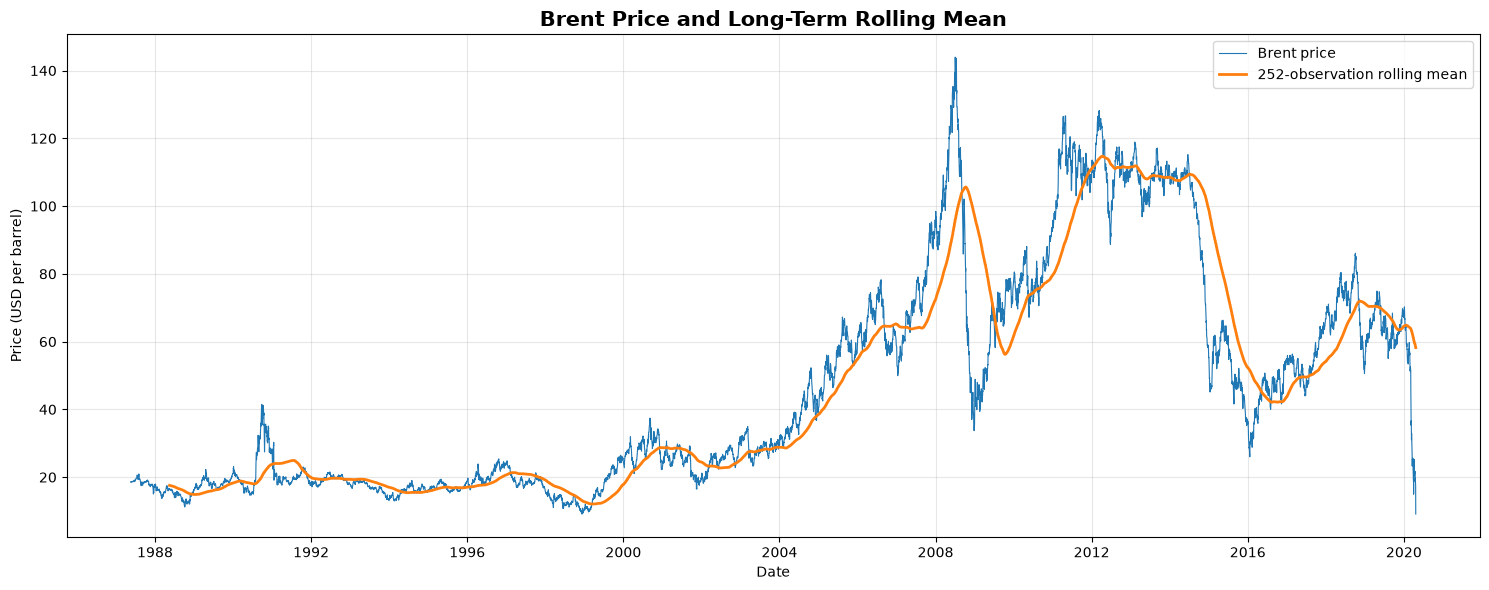

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_stationarity_evidence.png


In [11]:
stationarity_df = df.copy()

stationarity_df["Price_Rolling_Mean"] = (
    stationarity_df["Price"]
    .rolling(window=252)
    .mean()
)

stationarity_df["Return_Rolling_Mean"] = (
    stationarity_df["Log_Return"]
    .rolling(window=252)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    stationarity_df["Date"],
    stationarity_df["Price"],
    linewidth=0.8,
    label="Brent price"
)

plt.plot(
    stationarity_df["Date"],
    stationarity_df["Price_Rolling_Mean"],
    linewidth=2,
    label="252-observation rolling mean"
)

plt.title(
    "Brent Price and Long-Term Rolling Mean",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

stationarity_figure = (
    figures_directory
    / "task2_stationarity_evidence.png"
)

plt.savefig(
    stationarity_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", stationarity_figure)

### Stationarity interpretation

The raw Brent price series displays a changing long-term mean, indicating that its statistical behaviour is not stable across the complete historical period.

The Augmented Dickey-Fuller test results should be interpreted using the reported p-values:

- A p-value below 0.05 provides evidence against the null hypothesis of a unit root.
- A p-value greater than or equal to 0.05 means the analysis fails to reject the unit-root hypothesis.

Log returns are expected to exhibit more stable statistical behaviour than raw price levels, although they still demonstrate time-varying volatility.